In [ ]:
# Data collection command:
# `python comet_download.py --project=generalization-paper-v4-ns-feature-search-hyper-sweep --n_threads=8`

In [1]:
from collections import defaultdict
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from phd.feature_search.analysis.analysis_utils import *
from phd.feature_search.analysis.plotting import plot_learning_curves, plot_param_sensitivity

sns.set_theme('notebook', 'white')
%matplotlib inline

In [8]:
save_path = 'figures/'
config_data_path = 'data/generalization-paper-v4-ns-feature-search-hyper-sweep_params.csv'
run_data_path = 'data/generalization-paper-v4-ns-feature-search-hyper-sweep_metrics.csv'

config_dfs, run_dfs = load_experiment_data(config_data_path, run_data_path)
# del config_dfs[np.nan], run_dfs[np.nan]

{k: len(v) for k, v in config_dfs.items()}

{'ideal_features_baseline': 5,
 'learned_features_baseline': 5,
 'shadow_feature_sweep': 640}

In [9]:
print("_____Best Hyperparameter Configurations_____")

best_config_dfs, best_run_dfs, best_hyperparam_vals = get_best_ablation_values(
    config_dfs, run_dfs)

_____Best Hyperparameter Configurations_____

=== ideal_features_baseline ===

Configuration: (no split vars) | # runs: 5


=== learned_features_baseline ===

Configuration: (no split vars) | # runs: 5


=== shadow_feature_sweep ===

Configuration: (no split vars) | # runs: 5
  Best feature_recycling|recycle_rate=0.01
  Best optimizer|learning_rate=2**-14
  Best optimizer|shadow_weight_threshold_factor=0.1



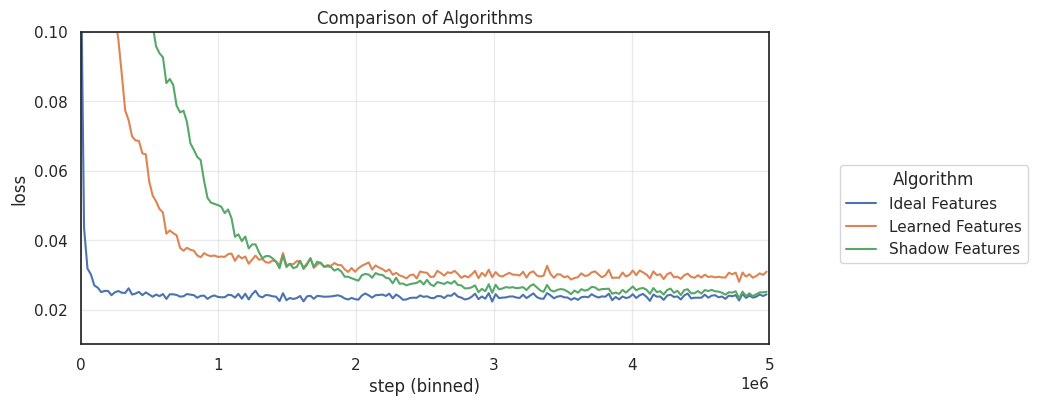

In [4]:
combined_run_df = pd.concat(list(best_run_dfs.values()))
combined_config_df = pd.concat(
    [df.assign(split_name=k) for k, df in best_config_dfs.items()]
)

algo_map = {
    'ideal_features_baseline': 'Ideal Features',
    'learned_features_baseline': 'Learned Features',
    'shadow_feature_sweep': 'Shadow Features',
}

# Only keep rows whose split_name is in algo_map
combined_config_df = combined_config_df[combined_config_df['split_name'].isin(algo_map.keys())].copy()
valid_run_ids = combined_config_df['run_id'].unique()
combined_run_df = combined_run_df[combined_run_df['run_id'].isin(valid_run_ids)].copy()
combined_config_df['algo'] = combined_config_df['split_name'].map(algo_map)


plot_learning_curves(
    run_df = combined_run_df,
    config_df = combined_config_df,
    n_bins = 200,
    figsize = (8, 4),
    hue_col = 'algo',
    legend_title = 'Algorithm',
)
plt.ylim(0.01, 0.1)
plt.title('Comparison of Algorithms')
plt.show()

# NOTE: THIS IS ONLY ACTUALLY DOING BETTER BECAUSE THE RECYLING RATE IS HIGHER THAN THE AUTOSTEP BASELINE
#       SHADOW FEATURES DONT ACTUALLY MATTER HERE

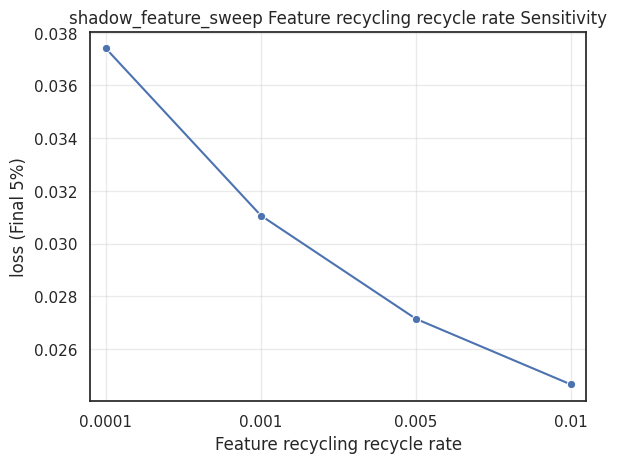

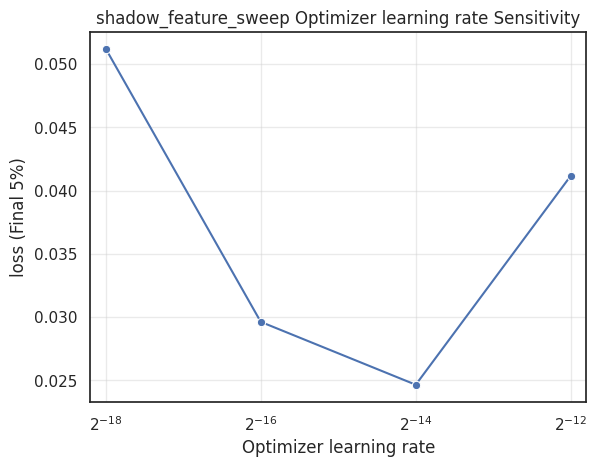

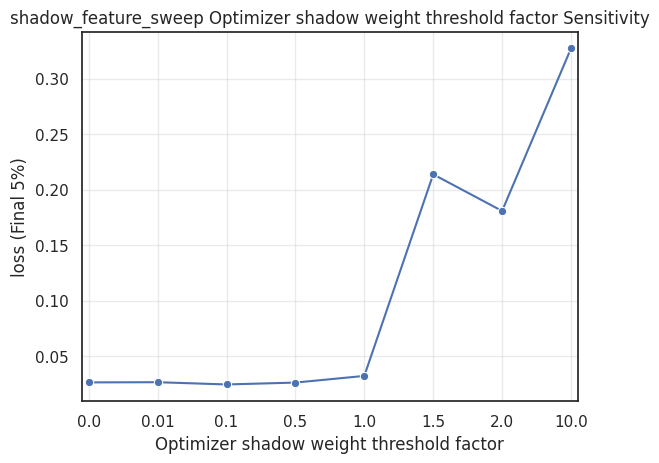

In [7]:
sensitivity_sweep_names = ['shadow_feature_sweep']

for target_df in sensitivity_sweep_names:
    default_hyperparams = best_hyperparam_vals[target_df]

    plot_config_df = config_dfs[target_df]
    valid_run_ids = plot_config_df['run_id'].unique()
    plot_run_df = run_dfs[target_df][run_dfs[target_df]['run_id'].isin(valid_run_ids)].copy()

    for param_name, param_value in default_hyperparams.items():
        selected_run_df, selected_config_df = select_experiment_runs(
            run_df = plot_run_df,
            config_df = plot_config_df,
            chosen_values = {
                k: v for k, v in default_hyperparams.items()
                if k != param_name
            },
        )
        
        param_label = param_name.replace('|', ' ').replace('_', ' ').capitalize()
        
        plot_param_sensitivity(
                run_df = selected_run_df,
                config_df = selected_config_df,
                x_col = param_name,
                title = f'{target_df} {param_label} Sensitivity',
                x_label = param_label,
                y_label = 'loss',
                metric_col = 'loss',
                metric_type = 'final_avg', # {'cumulative', 'final_avg', 'last'}
                step_col = 'step',
                legend_title = None,
                show_ci = False,
                baseline_col = None,
                pow_2_x_axis = 'learning_rate' in param_name,
                pow_2_legend = True,
            )
        plt.show()

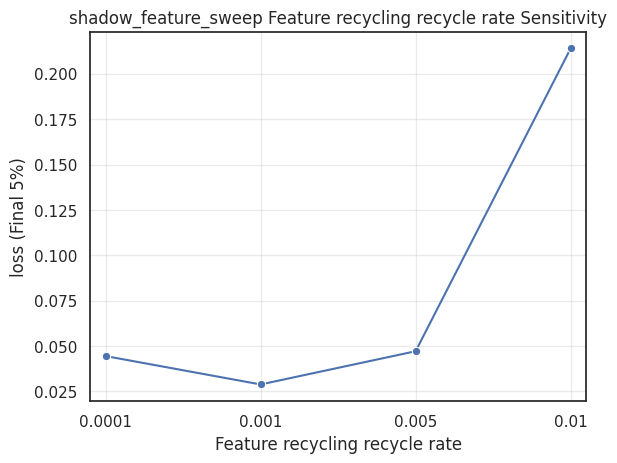

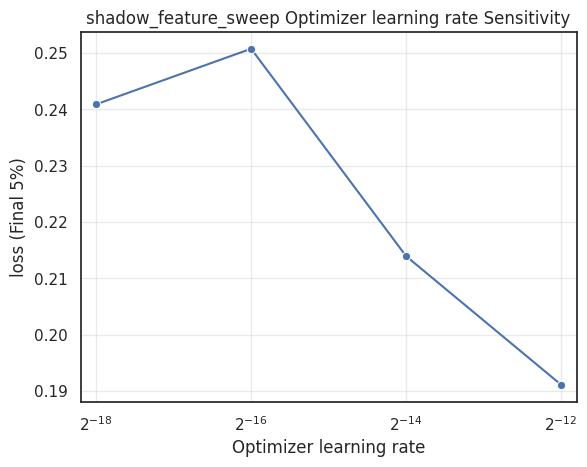

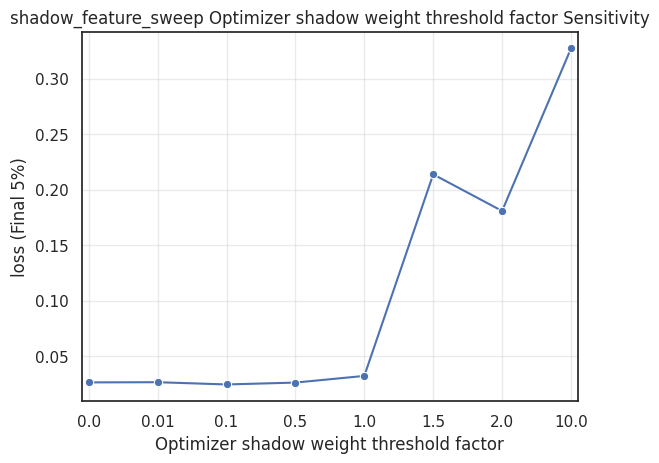

In [12]:
target_df = 'shadow_feature_sweep'
plot_config_df = config_dfs[target_df]
valid_run_ids = plot_config_df['run_id'].unique()
plot_run_df = run_dfs[target_df][run_dfs[target_df]['run_id'].isin(valid_run_ids)].copy()

default_hyperparams = best_hyperparam_vals['shadow_feature_sweep'].copy()
default_hyperparams['optimizer|shadow_weight_threshold_factor'] = 1.5

for param_name, param_value in default_hyperparams.items():
    selected_run_df, selected_config_df = select_experiment_runs(
        run_df = plot_run_df,
        config_df = plot_config_df,
        chosen_values = {
            k: v for k, v in default_hyperparams.items()
            if k != param_name
        },
    )
    
    param_label = param_name.replace('|', ' ').replace('_', ' ').capitalize()
    
    plot_param_sensitivity(
            run_df = selected_run_df,
            config_df = selected_config_df,
            x_col = param_name,
            title = f'{target_df} {param_label} Sensitivity',
            x_label = param_label,
            y_label = 'loss',
            metric_col = 'loss',
            metric_type = 'final_avg', # {'cumulative', 'final_avg', 'last'}
            step_col = 'step',
            legend_title = None,
            show_ci = False,
            baseline_col = None,
            pow_2_x_axis = 'learning_rate' in param_name,
            pow_2_legend = True,
        )
    plt.show()